# Fase Final: Guardado del EEG Procesado

## Objetivo
Almacenar la versión limpia del EEG para su uso en análisis posteriores sin necesidad de repetir el preprocesamiento.

## Procedimiento realizado previamente
Antes de guardar el archivo se realizaron los siguientes pasos:

- Corrección de tipos de canal (EOG, misc, stim)
- Eliminación de canales no relevantes
- Aplicación de filtro pasa-banda (1–40 Hz)
- Eliminación de ruido eléctrico mediante filtro notch a 60 Hz

## Justificación
Guardar el archivo procesado es fundamental porque:

- Permite mantener separación entre datos crudos (`raw`) y datos procesados (`processed`)
- Garantiza reproducibilidad científica
- Evita repetir procesos computacionalmente costosos
- Facilita el trabajo en fases posteriores del análisis

## Resultado esperado
Se genera un archivo en formato `.fif`, estándar de MNE, almacenado en:

`data/processed/eeg_clean/`

Este archivo será la base para la siguiente fase del proyecto: segmentación en epochs y análisis estadístico.

In [2]:
import mne
import numpy as np
from pathlib import Path

In [3]:
# Cargar archivo crudo nuevamente (siempre desde raw)
bdf_path = Path("../data/raw/eeg/subject-47-eeg_2023-03-30.bdf")

raw = mne.io.read_raw_bdf(
    bdf_path,
    preload=True
)

raw


Extracting BDF parameters from ../data/raw/eeg/subject-47-eeg_2023-03-30.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1090499  =      0.000 ...  2180.998 secs...


<RawBDF | subject-47-eeg_2023-03-30.bdf, 26 x 1090500 (2181.0 s), ~216.3 MiB, data loaded>

## Corrección de tipos de canal

In [15]:
# Marcar canales que NO son EEG correctamente
raw.set_channel_types({
    "ExG 1": "eog",
    "ACC21": "misc",
    "ACC22": "misc",
    "ACC23": "misc",
    "Packet Counter": "misc"
})

raw.get_channel_types()


['eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eeg',
 'eog',
 'misc',
 'misc',
 'misc',
 'misc',
 'stim']

## Eliminar canales no necesarios para análisis EEG

In [17]:
# Crear copia antes de modificar (buena práctica científica)
raw_clean = raw.copy()

raw_clean.drop_channels([
    "ACC21",
    "ACC22",
    "ACC23",
    "Packet Counter"
])

raw_clean


<RawBDF | subject-47-eeg_2023-03-30.bdf, 22 x 1090500 (2181.0 s), ~183.1 MiB, data loaded>

## Aplicar filtro pasa-banda (1–40 Hz)


In [25]:
raw_clean.filter(
    l_freq=1.0,
    h_freq=40.0
)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)



<RawBDF | subject-47-eeg_2023-03-30.bdf, 22 x 1090500 (2181.0 s), ~183.1 MiB, data loaded>

## Eliminar ruido eléctrico (Notch Filter 60 Hz)

In [31]:
raw_clean.notch_filter(freqs=[60])


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 3301 samples (6.602 s)



<RawBDF | subject-47-eeg_2023-03-30.bdf, 22 x 1090500 (2181.0 s), ~183.1 MiB, data loaded>

## Visualizar señal ya filtrada

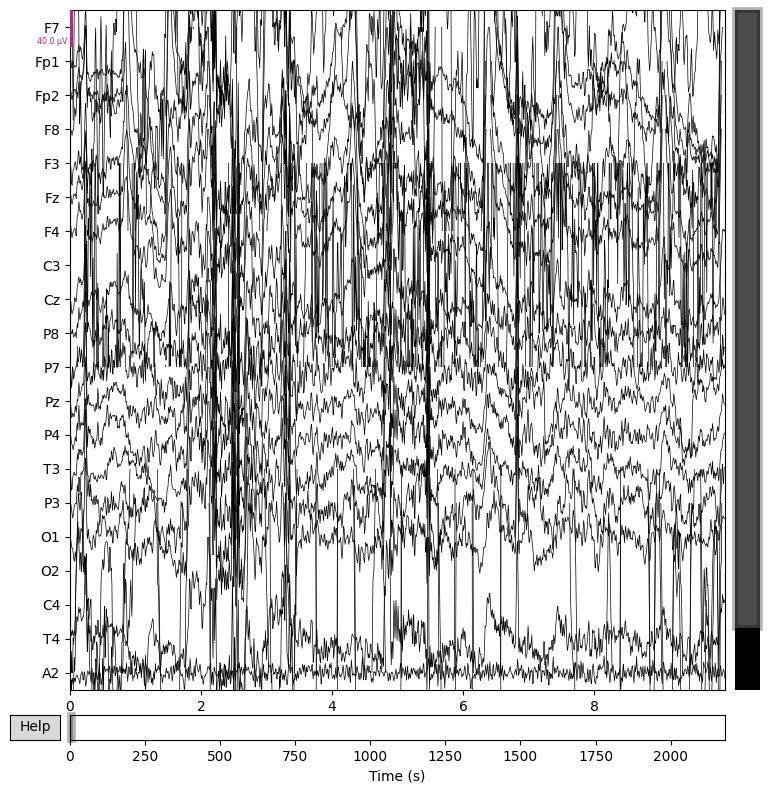

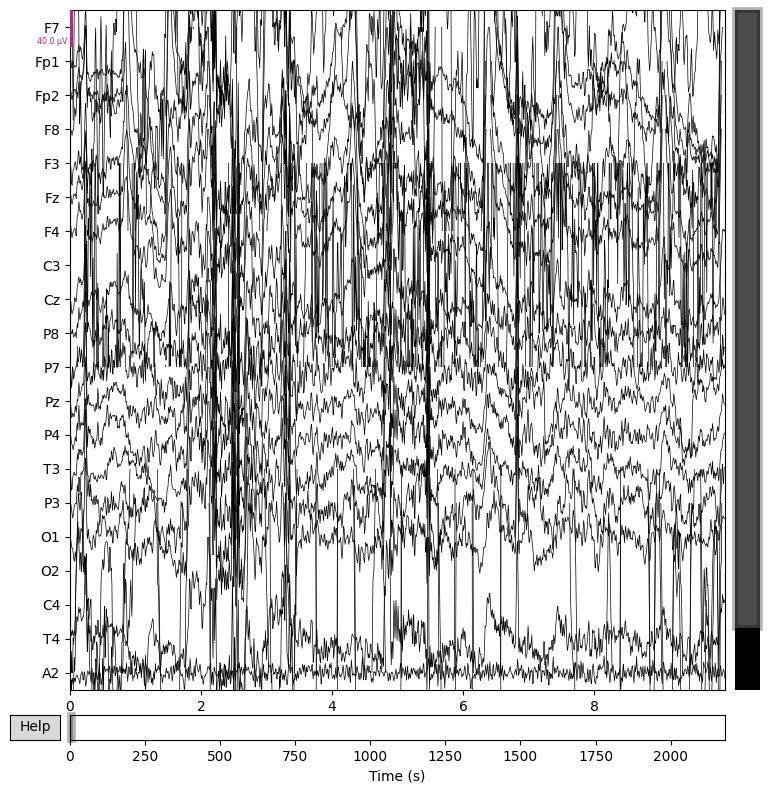

In [36]:
raw_clean.plot()


## Guardar EEG limpio

In [39]:
output_path = Path("../data/processed/eeg_clean")
output_path.mkdir(parents=True, exist_ok=True)

clean_file = output_path / "subject-47_clean_raw.fif"

raw_clean.save(clean_file, overwrite=True)

clean_file


Overwriting existing file.
Writing /Users/hectorjesus/PycharmProjects/Cientifico_de_datos_Proyecto_Prueba/notebooks/../data/processed/eeg_clean/subject-47_clean_raw.fif
Overwriting existing file.
Closing /Users/hectorjesus/PycharmProjects/Cientifico_de_datos_Proyecto_Prueba/notebooks/../data/processed/eeg_clean/subject-47_clean_raw.fif
[done]


PosixPath('../data/processed/eeg_clean/subject-47_clean_raw.fif')